# Section 00 - Getting ready

In [270]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In this exercise, we will revisit how to do a correlation analysis and potential pitfalls of correlation
analysis. 

We will use the gene expression data in cancer_data.txt which stores the expression of 20
genes across 30 different tumor samples. 

Gene expression measures the abundance of RNAs per gene and is indicative of how active a gene is in a sample. If the expression of a gene differs a lot between
conditions (e.g. healthy versus cancer or different cancer types) it could hint that this gene plays an
important role in this context.

In [271]:
expr = pd.read_csv('../Datasets/Exercise2_datasets/Exercise5DATA.csv', sep = '\t')
print(expr.shape)

display(expr.head())

(30, 20)


,MYC,SRM,GBE1,FUK,UGP2,PRDX6,ATP6V1A,BCAT1,GLUD1,ATP6V1B2,GGPS1,POLD1,CAD,ALOX5,ASNS,PYCRL,PLCG2,GANAB,SEPHS1,GLUD2
DOHH2,-0.495015,0.209073,-0.436673,100.000000,100.000000,-0.208583,-0.051411,0.197500,-1.588511,0.606414,1.015733,0.431621,1.086766,0.235469,-0.338655,0.377149,-0.541951,0.119991,-0.792206,-0.753164
FARAGE,-0.491363,-0.355909,0.532208,0.103754,-0.649490,0.853678,0.582783,1.116467,1.350061,0.050270,-0.737583,-1.629394,0.160081,0.248119,-0.073632,-0.586918,0.232701,-0.470425,-1.031687,-0.139834
HT,-0.455994,-0.238525,0.671424,-1.013636,-0.965129,-0.480404,-0.923247,-1.124617,-0.319750,0.580138,-0.125961,-0.457667,-0.251649,-1.363059,-0.929329,0.298543,-0.101672,-0.197600,0.881220,-0.493419
Kapas231,1.615267,0.926663,1.016815,-0.997896,1.006484,1.121718,2.622680,-0.139736,1.082747,0.609479,-1.723106,-0.066013,-1.580867,1.892489,0.786433,-0.346331,1.042389,1.062637,-1.525772,2.024821
OCI-LY1,0.494273,2.400626,-1.425517,1.067607,0.986218,1.039540,-1.831517,-2.251518,-0.901666,-1.760212,1.225166,3.029640,0.583410,1.702037,1.899529,3.814041,1.975792,1.437689,1.025885,-2.137486


1. We are interested in the correlations between genes. Plot the pairwise correlations of the variables in
the dataset. Which pair of genes has the highest correlation? Hint: you can use the correlation method
pd.DataFrame.corr() and the plotting function sns.clustermap.

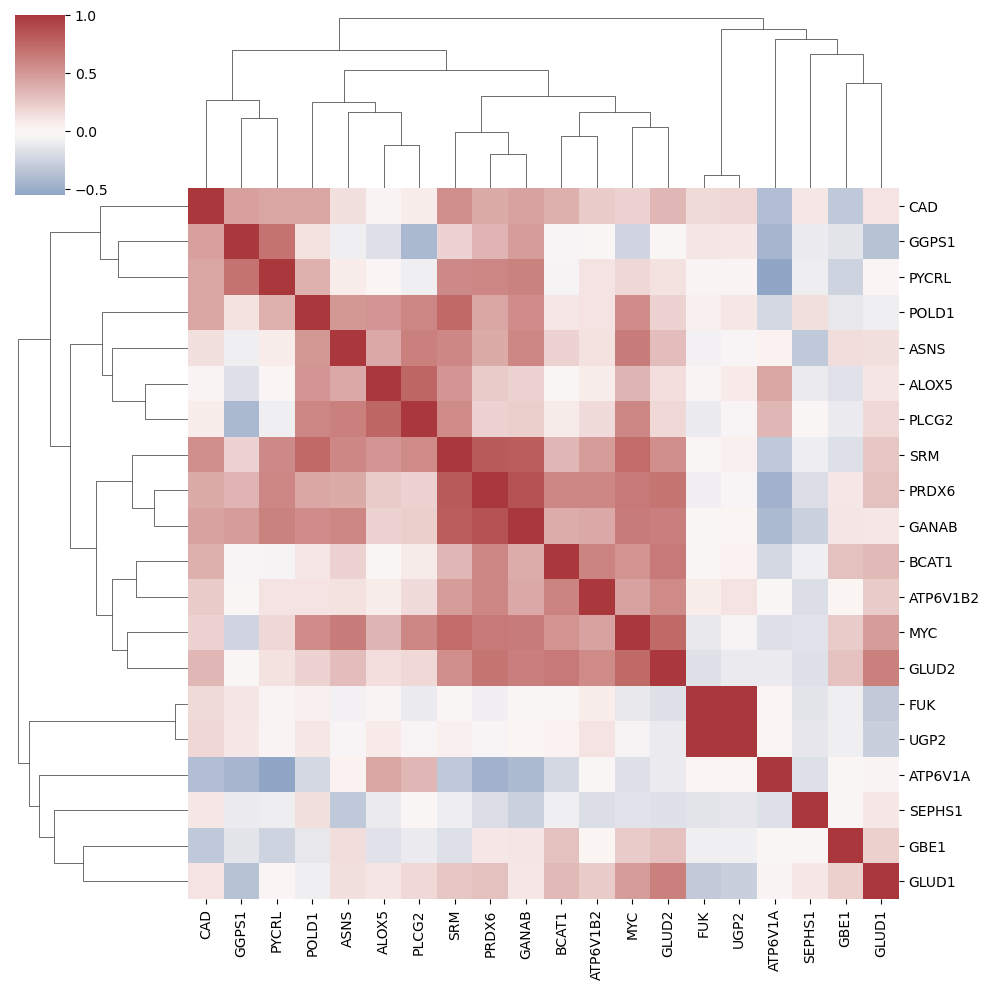

In [272]:
sns.clustermap(expr.corr(), cmap = 'vlag', center = 0)

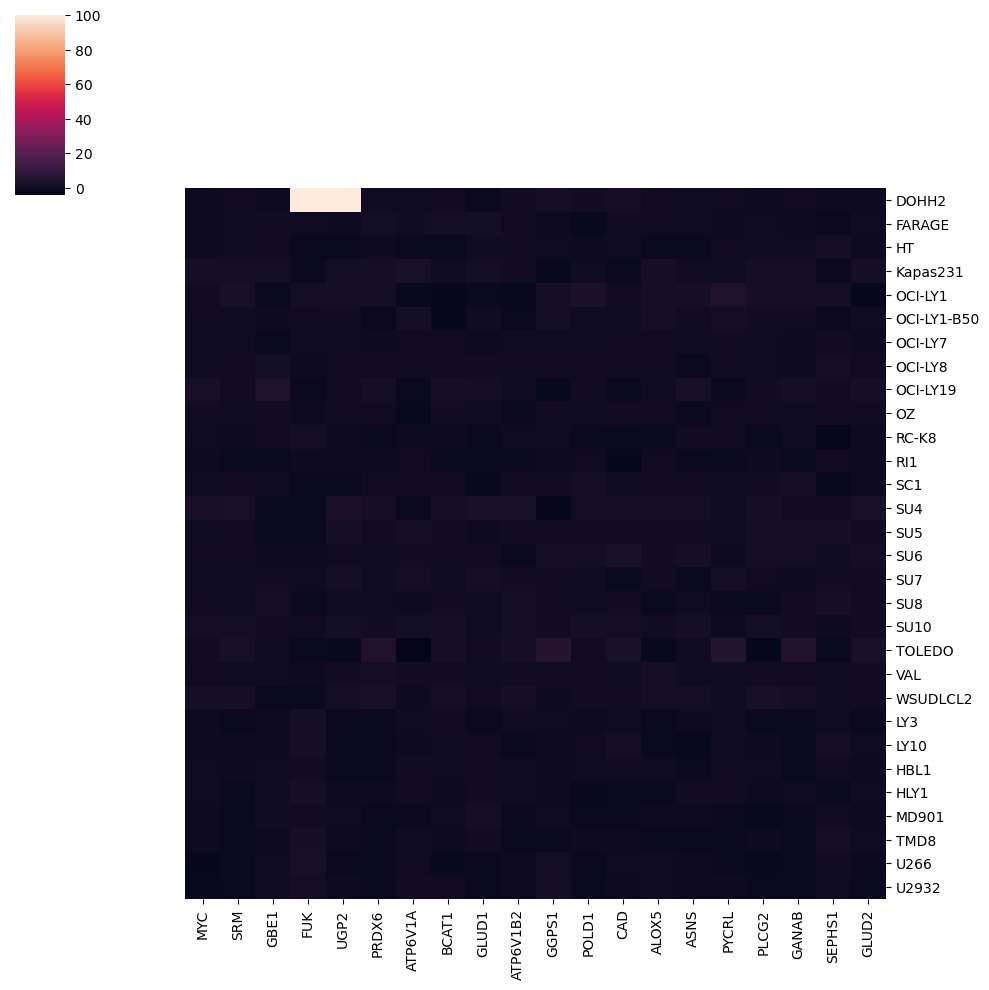

In [273]:
sns.clustermap(expr, col_cluster= False, row_cluster= False)

3. Does the latter plot suggest some outliers? Could they have affected the correlations? Check by using
an appropriate plot the impact of these outliers on the correlations in question 1. Substitute them with
missing values (NA) and redo the previous questions 1 and 2.

Obviously two data points are completely off –> find them

In [274]:
expr.melt(ignore_index= False).sort_values(by = 'value', ascending= False)

,variable,value
DOHH2,UGP2,100.000000
DOHH2,FUK,100.000000
TOLEDO,GGPS1,5.876502
TOLEDO,PYCRL,5.555931
TOLEDO,PRDX6,4.789574
...,...,...
U266,MYC,-2.382148
RC-K8,SEPHS1,-2.576766
SU4,GGPS1,-2.592600
TOLEDO,PLCG2,-2.793202


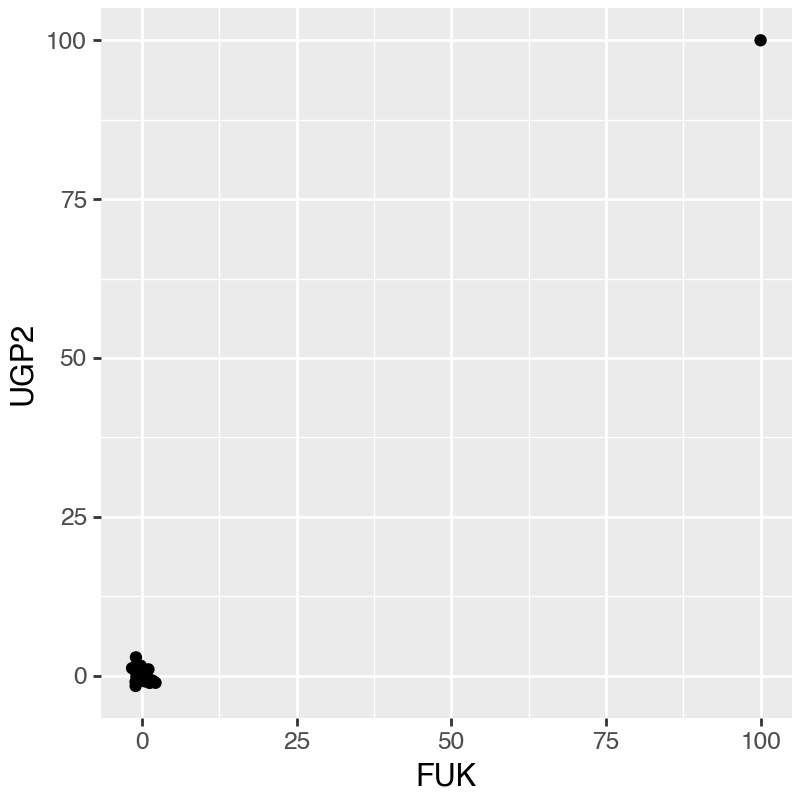

In [275]:
(
    ggplot(expr, aes('FUK', 'UGP2')) +
    geom_point() +
    theme(figure_size= (4,4))
)

We can substitute the outlier with NA

In [276]:
expr.loc['DOHH2', ['UGP2','FUK']] = np.nan

Now check the correlation again. We see that the two genes that were previously highly correlated do not
show a high correlation after removing the outliers. Lesson learned: always have a look at the raw data
when doing a correlation analysis.

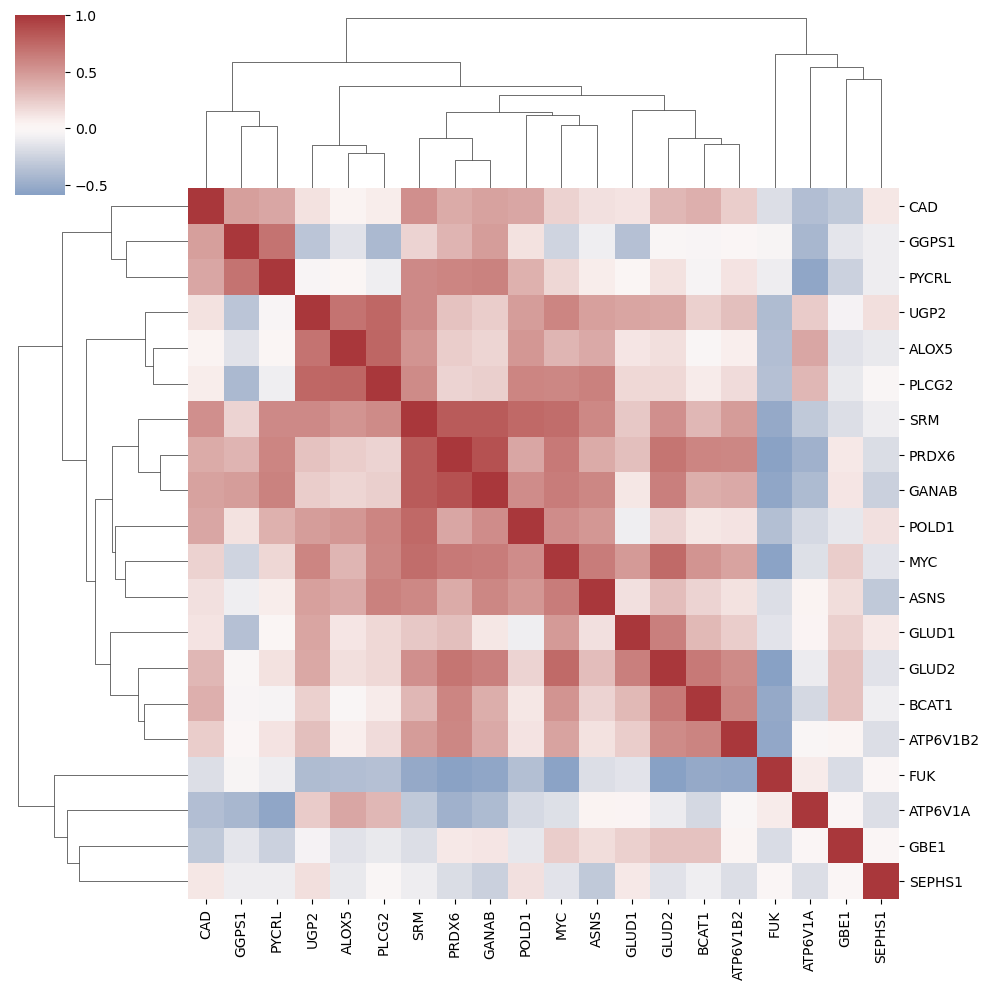

In [277]:
sns.clustermap(expr.corr(), cmap = 'vlag', center = 0)

Now plot heatmap again. We can see that all the values are now in a similar range.

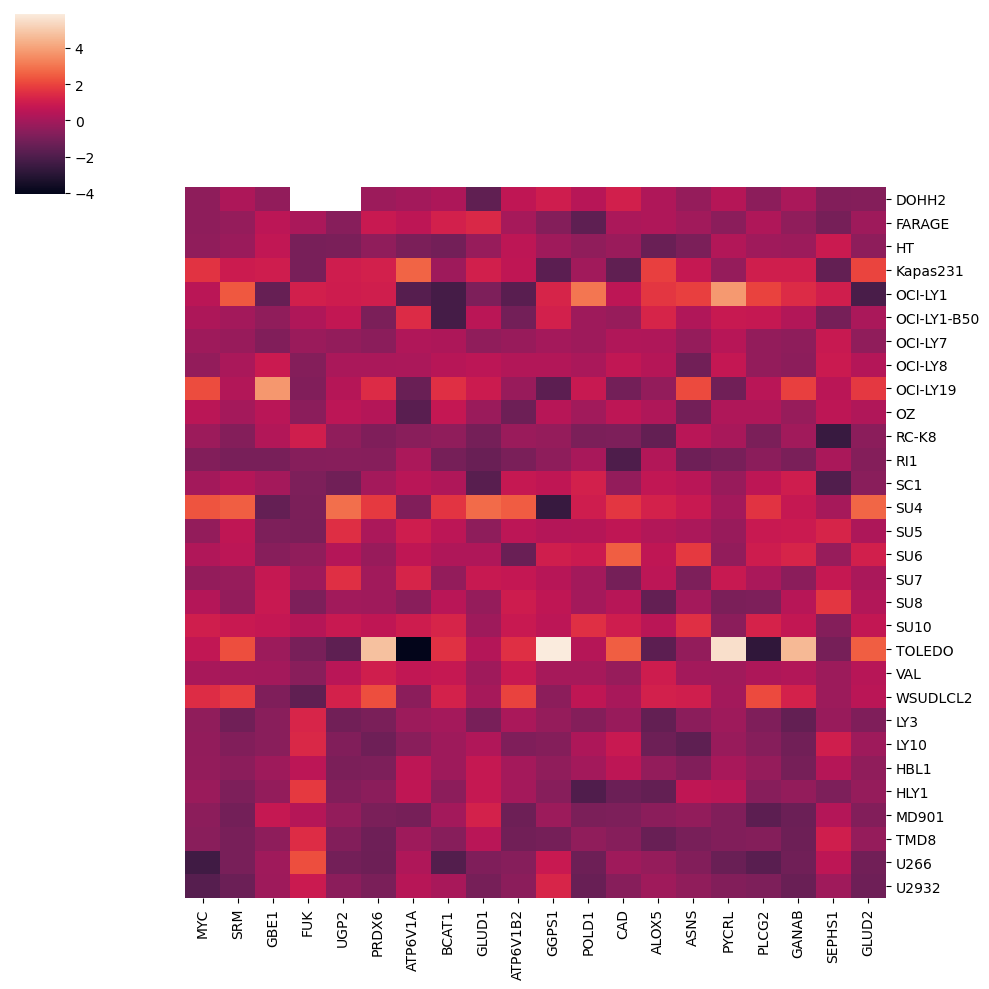

In [278]:
sns.clustermap(expr,row_cluster= False, col_cluster= False)

----

# Section 02 - Heatmaps and Hierarchical clustering

1. Consider the full iris data set without the Species column for clustering. Create a pretty heatmap
with the library sns.clustermap of the data without clustering.

In [279]:
iris = sklearn.datasets.load_iris(as_frame=True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


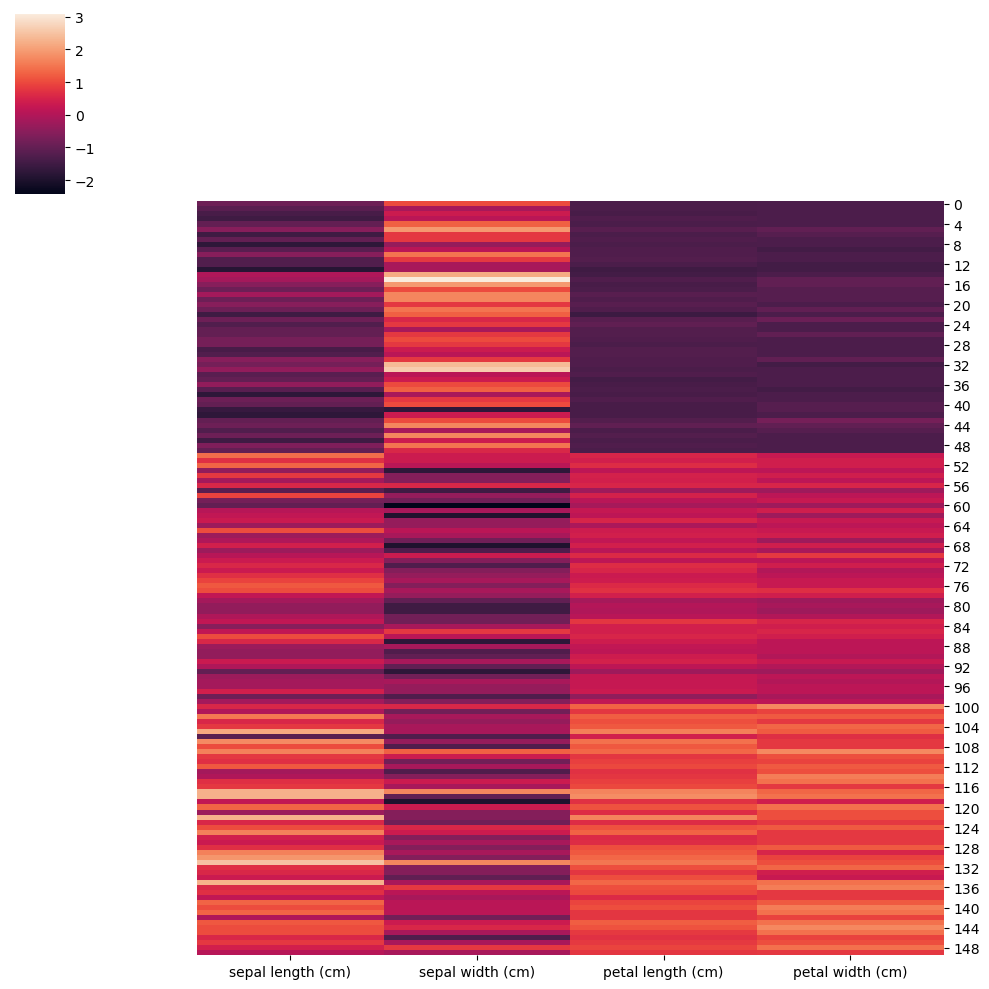

In [280]:
sns.clustermap(iris_df.iloc[:,:-1], row_cluster= False, col_cluster= False, z_score= 1)

2. Now, create a pretty heatmap using complete linkage clustering of the rows of the data set. Hint:
You can specify a clustering method with the method argument in sns.clustermap

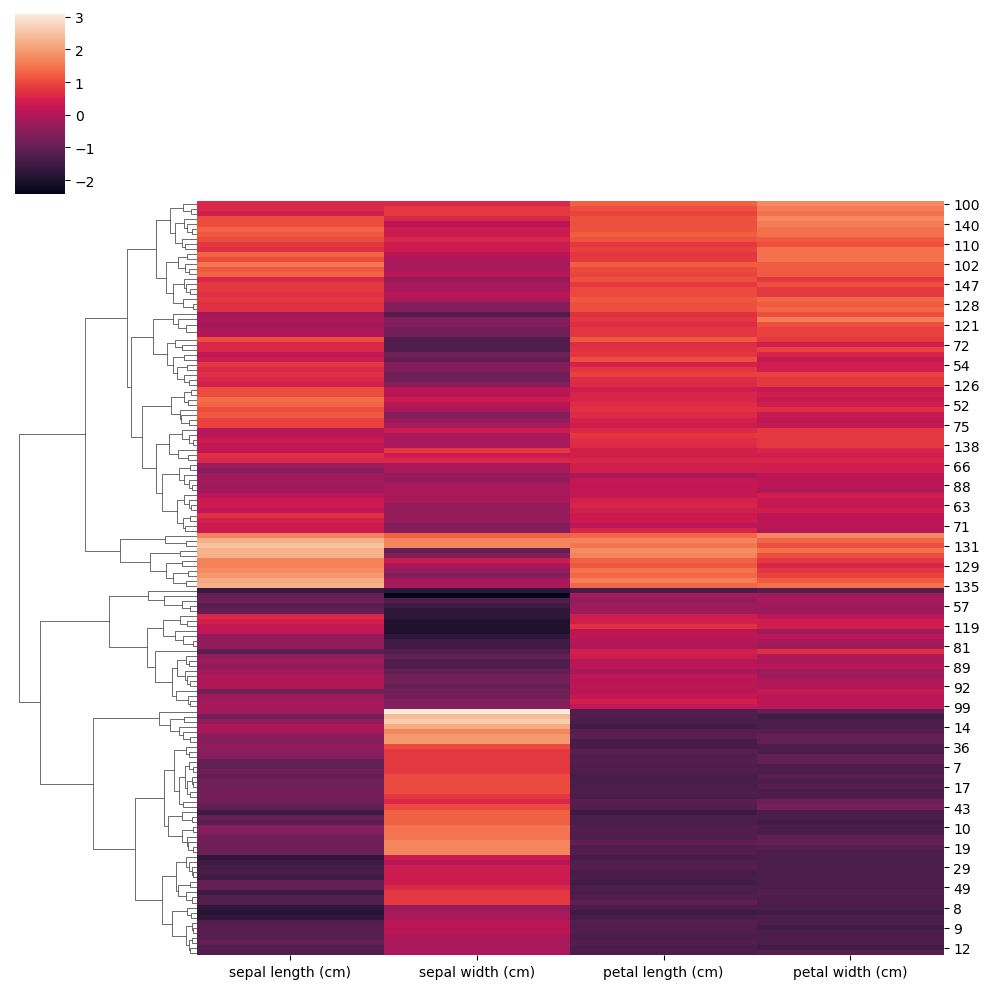

In [281]:
sns.clustermap(iris_df.iloc[:, :-1], row_cluster= True, col_cluster= False, method= 'complete', z_score= 1)

3. Compute the row clustering using complete linkage clustering and partition the data into 3 clusters.

Hint: You can use sklearn.cluster.AgglomerativeClustering().

In [282]:
X = sklearn.preprocessing.StandardScaler().fit_transform(iris_df.iloc[:,:-1])
hc_sklearn = sklearn.cluster.AgglomerativeClustering(linkage = 'complete', n_clusters= 3).fit(X)

In [283]:
hc_sklearn.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0,
       0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 0, 0, 2,
       0, 2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

4. Annotate the rows of the heatmap with the Species column of the iris dataset and the three clusters
from complete linkage clustering. What do you observe when you compare the clustering and the species
labels?

In [284]:
row_ann = pd.DataFrame({"species":iris_df.iloc[:,-1],"hc":["C"+str(s) for s in hc_sklearn.labels_]}, \
index = iris_df.index)

row_ann.head()

,species,hc
0,setosa,C1
1,setosa,C1
2,setosa,C1
3,setosa,C1
4,setosa,C1


In [285]:
unique_categories = np.unique(row_ann.values)
unique_categories

array(['C0', 'C1', 'C2', 'setosa', 'versicolor', 'virginica'],
      dtype=object)

In [286]:
palette = sns.color_palette("husl", len(unique_categories))
palette

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.7350228985632719, 0.5952719904750953, 0.1944419133847522),
 (0.3126890019504329, 0.6928754610296064, 0.1923704830330379),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.23299120924703914, 0.639586552066035, 0.9260706093977744),
 (0.9082572436765556, 0.40195790729656516, 0.9576909250290225)]

In [287]:
color_mapping = dict(zip(unique_categories, palette))

In [288]:
row_col = row_ann.map(lambda x : color_mapping[x])
row_col.head()

,species,hc
0,"(0.21044753832183283, 0.6773105080456748, 0.64...","(0.7350228985632719, 0.5952719904750953, 0.194..."
1,"(0.21044753832183283, 0.6773105080456748, 0.64...","(0.7350228985632719, 0.5952719904750953, 0.194..."
2,"(0.21044753832183283, 0.6773105080456748, 0.64...","(0.7350228985632719, 0.5952719904750953, 0.194..."
3,"(0.21044753832183283, 0.6773105080456748, 0.64...","(0.7350228985632719, 0.5952719904750953, 0.194..."
4,"(0.21044753832183283, 0.6773105080456748, 0.64...","(0.7350228985632719, 0.5952719904750953, 0.194..."


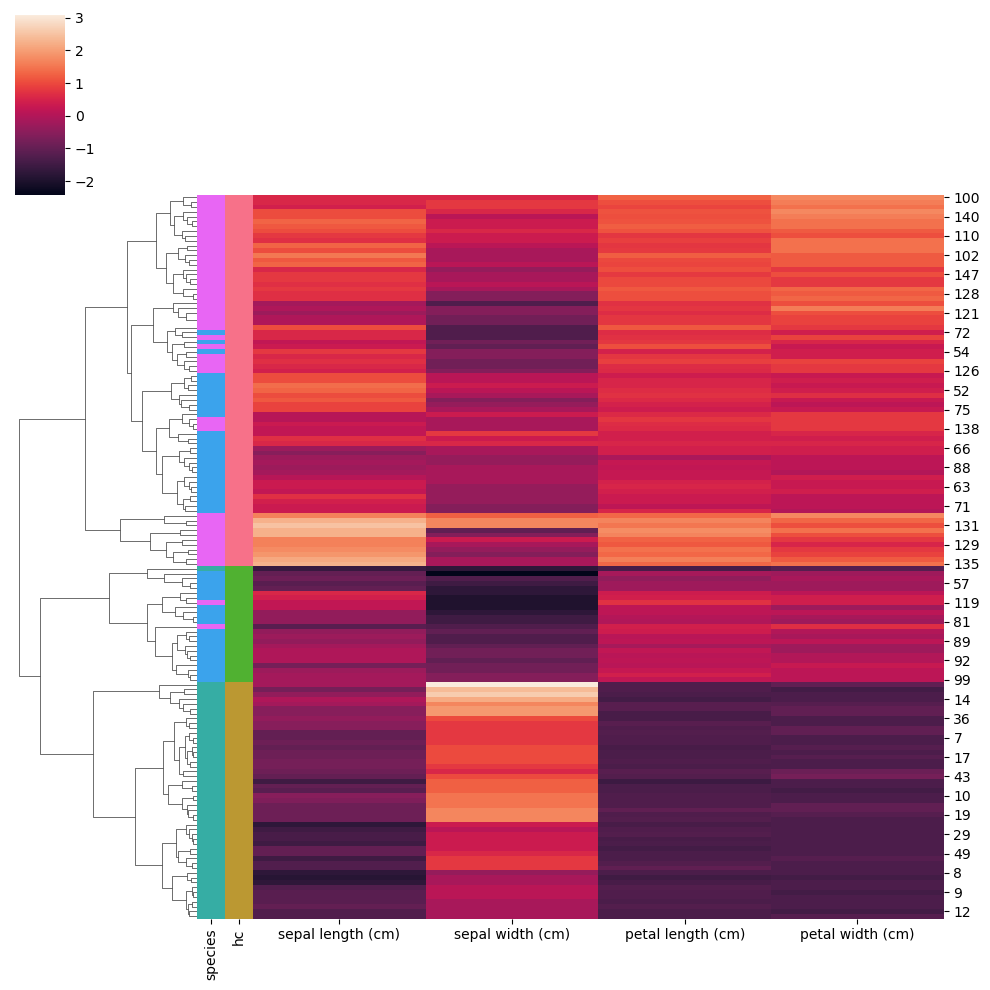

In [289]:
sns.clustermap(iris_df.iloc[:,:-1], row_colors=row_col, col_cluster=False, \
z_score=1, method="complete")

We observe that the complete linkage method is able to correctly classify the setosa species, but makes 2
subclusters for the other 2 species. We can explore other methods to see if they are able to distinguish
between the different species better.

-----

# Homework

# Section 03 - Clustering and Heatmaps

In this section, we aim to compare two different clustering algorithms - hierarchical clustering and k-means
clustering.

1. This plot represents a random initialization of a k-means algorithm with k=2. X1, X2 are the randomly
positioned centroids and A to E are the points of the 2-dimensional dataset. Calculate the new positions
of the centroids after the first iteration using the Euclidean distance. Hint: You can solve this exercise
either with pen and paper or using Python.

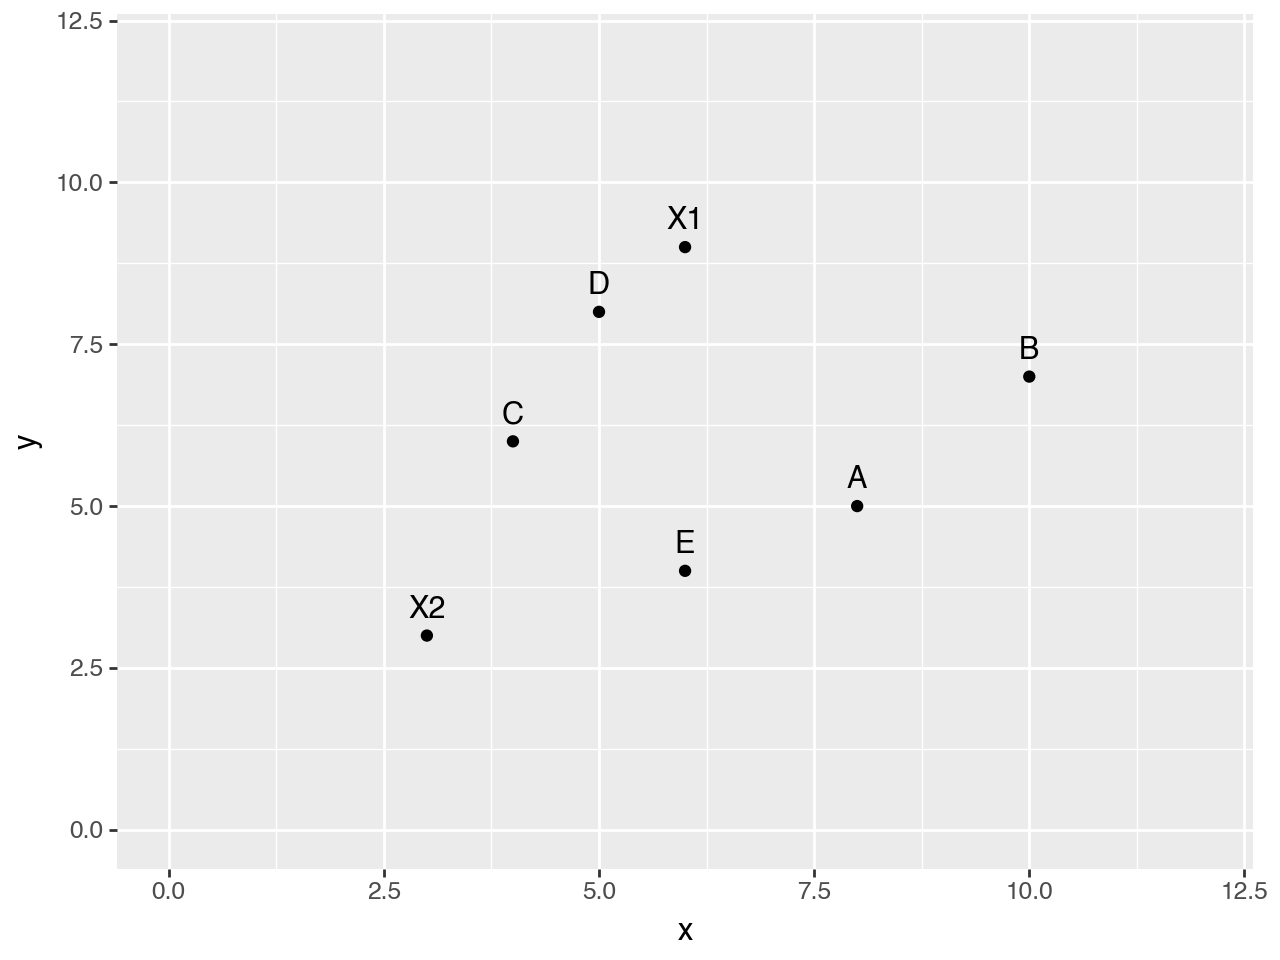

In [290]:
df = pd.DataFrame({
    'point': ['A', 'B', 'C', 'D', 'E', 'X1', 'X2'],
    'x': [8, 10, 4, 5, 6, 6, 3],
    'y': [5, 7, 6, 8, 4, 9, 3]
})

(
    ggplot(df, aes('x', 'y')) + 
    geom_point() + 
    geom_text(aes(label= 'point'), nudge_y = 0.4) +
    xlim(0, 12) +
    ylim(0,12)
)

In [291]:
x1x, x1y = df.loc[ df['point'] == 'X1', ['x', 'y']].iloc[0]
x2x, x2y = df.loc[ df['point'] == 'X2', ['x', 'y']].iloc[0]

In [292]:
df['delta_x1x'] = df['x'] - x1x
df['delta_x1y'] = df['y'] - x1y
df['delta_x2x'] = df['x'] - x2x
df['delta_x2y'] = df['y'] - x2y

In [293]:
df['distance_x1'] = np.sqrt(df['delta_x1x']**2 + df['delta_x1y']**2)
df['distance_x2'] = np.sqrt(df['delta_x2x']**2 + df['delta_x2y']**2)

In [294]:
df['cluster'] = np.where(df['distance_x1'] < df['distance_x2'], 'X1', 'X2')

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_99334/603025002.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.666666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_99334/603025002.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.666666666666667' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.


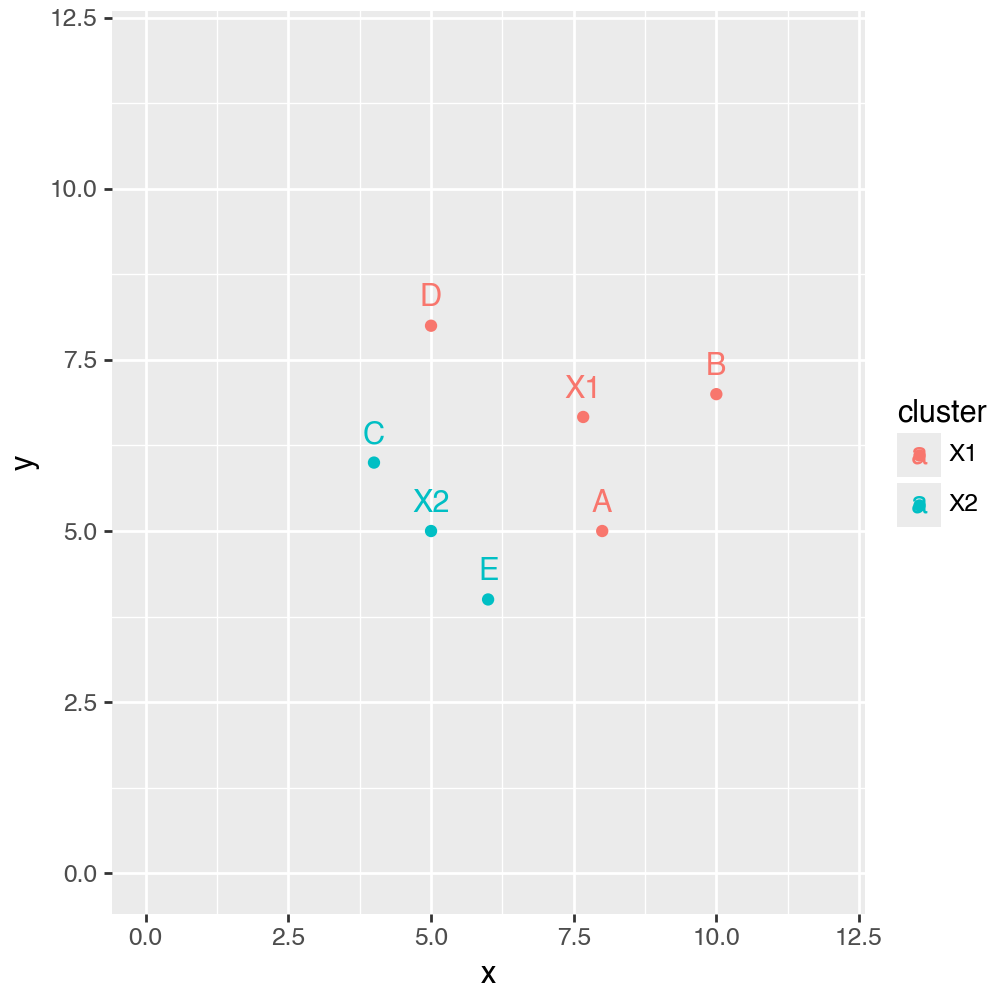

In [295]:
new_centroids = (
    df.iloc[:5]\
    .groupby('cluster').agg(
        xmean = ('x', 'mean'),
        ymean = ('y', 'mean')
    )
)

df.loc[ df['point']== 'X1', ['x','y']] = new_centroids.loc['X1'].values
df.loc[ df['point']== 'X2', ['x','y']] = new_centroids.loc['X2'].values


(
    ggplot(df, aes('x', 'y', color = 'cluster')) + 
    geom_point() + 
    geom_text(aes(label = 'point'), nudge_y = 0.4) + 
    theme(figure_size= (5,5)) + 
    xlim(0, 12) + 
    ylim(0, 12)
)

2. Perform k-means clustering on the iris data set with 𝑘 = 3

In [296]:
iris = sklearn.datasets.load_iris(as_frame= True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

In [297]:
X = sklearn.preprocessing.StandardScaler().fit_transform(iris_df.iloc[:,:-1])
km = sklearn.cluster.KMeans(n_clusters= 3, n_init= 50).fit(X)
km.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

3. Reproduce section 2 from the tutorial. Use the pd.DataFrame.value_counts() method to compare
the partitions from the complete linkage and k-means clustering.

In [298]:
pd.DataFrame({
    'hc' : hc_sklearn.labels_,
    'km' : km.labels_
}).value_counts().unstack()

km,0,1,2
hc,,,
0,NaN,47.0,30.0
1,49.0,NaN,NaN
2,1.0,NaN,23.0


4. Create a heatmap using complete clustering of the rows annotated with the species and both clustering
results - complete linkage clustering and the k-means clustering. What do you observe when you compare
the two different clustering algorithms and the species labels?

In [299]:
## create a data.frame for the row annotations
row_ann = pd.DataFrame({"species":iris_df.iloc[:,-1],"hc":["C"+str(s) for s in hc_sklearn.labels_], \
"km":["C"+str(s) for s in km.labels_]}, index = iris_df.index)

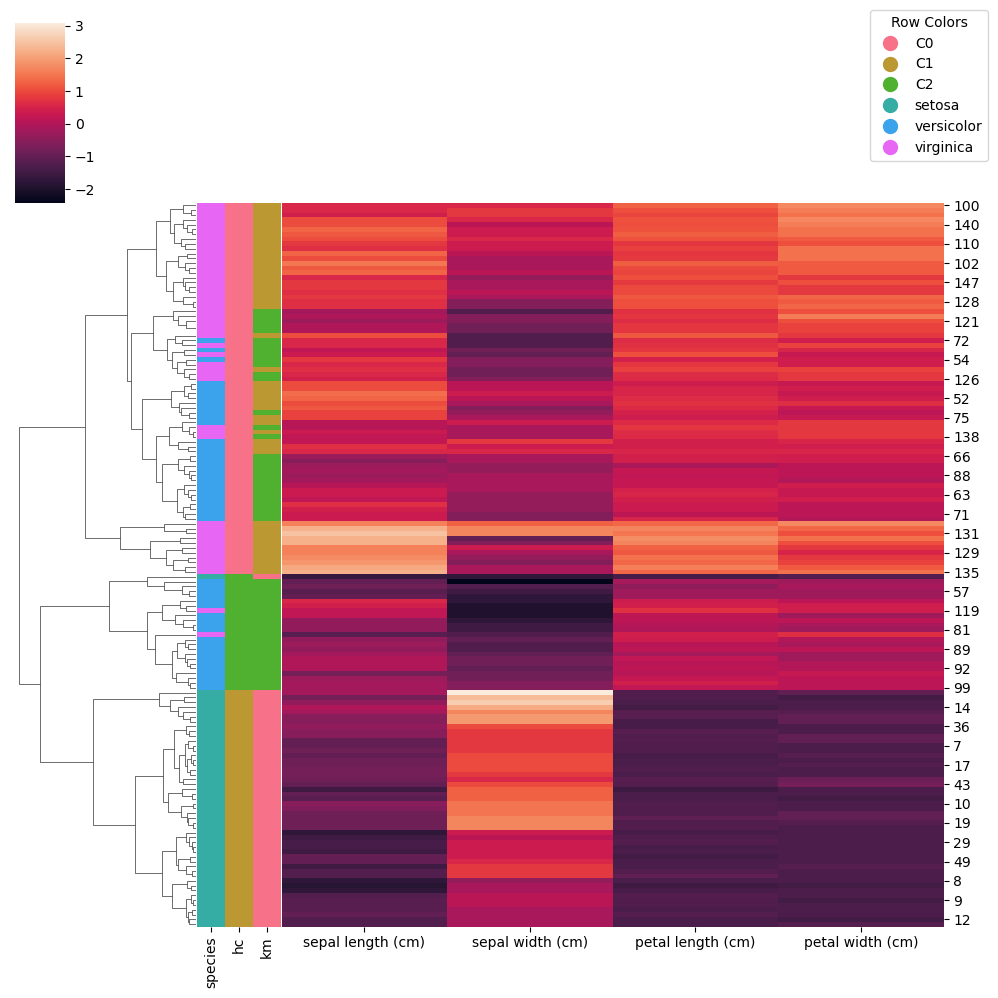

In [300]:
unique_categories = np.unique(row_ann)
palette = sns.color_palette('husl',len(unique_categories))
color_mapping = dict(zip(unique_categories, palette))

row_col = row_ann.map(lambda x : color_mapping[x])

sns.clustermap(iris_df.iloc[:,:-1], row_colors = row_col, col_cluster= False, z_score= 1, method= 'complete')

# Add legend
handles = [plt.Line2D([0], [0], marker='o', color=color_mapping[category], linestyle='', \
markersize=10) for category in unique_categories]

plt.legend(handles, unique_categories, title='Row Colors', bbox_to_anchor=(1, 1), \
bbox_transform=plt.gcf().transFigure)
plt.show()

----------

# Section 04 - Cluster Comparison

1. Compute the pairwise Rand indices between the clustering results from the previous sections (complete,
average and k-means) and species label. Hint: sklearn.metrics.rand_score().

In [301]:
X = sklearn.preprocessing.StandardScaler().fit_transform(iris_df.iloc[:,:-1])

hc_complete = sklearn.cluster.AgglomerativeClustering(linkage = 'complete', n_clusters= 3).fit(X)
hc_average  = sklearn.cluster.AgglomerativeClustering(linkage = 'average', n_clusters= 3).fit(X)
km = sklearn.cluster.KMeans(n_clusters= 3, n_init= 50).fit(X)

In [302]:
row_ann = pd.DataFrame({
    "species":iris_df.iloc[:,-1],
    "hc":["C"+str(s) for s in hc_complete.labels_], 
    "km":["C"+str(s) for s in km.labels_], 
    'ha':['C'+str(s) for s in hc_average.labels_]
    }, index = iris_df.index)

row_ann.head()


,species,hc,km,ha
0,setosa,C1,C1,C0
1,setosa,C1,C1,C0
2,setosa,C1,C1,C0
3,setosa,C1,C1,C0
4,setosa,C1,C1,C0


In [303]:
rand = row_ann.apply(lambda i : row_ann.apply(lambda j : sklearn.metrics.rand_score(i,j), axis = 0), axis= 0)

rand

,species,hc,km,ha
species,1.000000,0.802148,0.832215,0.777092
hc,0.802148,1.000000,0.805638,0.821387
km,0.832215,0.805638,1.000000,0.779508
ha,0.777092,0.821387,0.779508,1.000000


2. Visualize the pair wise Rand indices with a pretty heatmap. What is the best clustering in this scenario
according to the computed Rand indices?

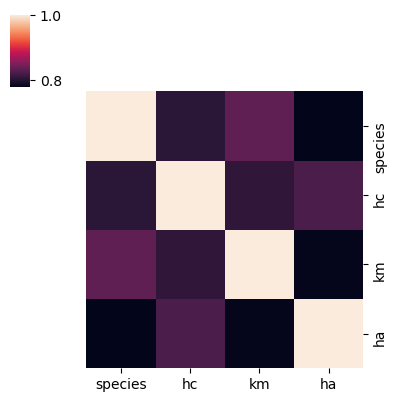

In [304]:
sns.clustermap(rand, row_cluster= False, col_cluster= False, figsize= (4,4))

-----

# Section 05 - Linkage methods in hierarchical clustering

1. These are the dendrograms after performing hierarchical clustering with Euclidean distances. In one,
“single” linkage method was used, while “complete” was used in the other. Which one corresponds to
which? Justify your answer.

<img src = '../images/Ekran Resmi 2026-02-09 00.21.00.png' width = 650>

The distance between clusters is defined as the shortest (in single) vs longest (in complete) distance from
any member of one cluster to any member of the other cluster. The height goes up to 10 in A vs 40 in B.
Therefore, A is single and B is complete.


Single linkage can result in extended, trailing clusters in which single observations are fused one-at-a-time,
while in complete linkage we usually fuse two clusters at the end.

-------

# Section 07 - Dimensionality reduction with PCA

1. Let 𝑋 be the iris data set without the Species column and only for the species setosa. Perform PCA
on 𝑋. Make sure that you scale and center the data before performing PCA.

In [305]:
iris = sklearn.datasets.load_iris(as_frame= True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
for s in iris['target']]

iris_pca = iris_df[iris_df['target'] == 'setosa']
iris_pca.drop(columns = 'target', inplace= True)
iris_pca.head()

/var/folders/nn/rd9y9hfx7qz4tk9cjwqs2xrh0000gn/T/ipykernel_99334/1853836495.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [306]:
# Standard Scale
X = sklearn.preprocessing.StandardScaler().fit_transform(iris_pca) 

pca_res = sklearn.decomposition.PCA().fit(X)

2. Which proportion of the variance is explained by each principle component?

In [307]:
sum_df = pd.DataFrame({
    'Variance': pca_res.explained_variance_,
    'Proportion of Variance': pca_res.explained_variance_ratio_,
    'Cumulative Proportion': np.cumsum(pca_res.explained_variance_ratio_)
}, index=[f'PC{i+1}' for i in range(pca_res.n_components_)])
sum_df

,Variance,Proportion of Variance,Cumulative Proportion
PC1,2.100551,0.514635,0.514635
PC2,1.043039,0.255545,0.770180
PC3,0.681449,0.166955,0.937135
PC4,0.256593,0.062865,1.000000


3. Compute the projection of 𝑋 from the PCA result and plot the projection on the first two principle components. 

Hint: PCA.transform(). Additionally, look at the biplot and come up with an interpretation
of the first principal component.

In [308]:
scores_df = pd.DataFrame(pca_res.transform(X), columns = [f'PC{i+1}' for i in range(len(pca_res.components_))])
scores_df.head()

,PC1,PC2,PC3,PC4
0,-0.039815,-0.642576,-0.097234,0.099546
1,-1.153210,0.136821,-0.057675,0.604718
2,-1.411224,-0.270827,0.374379,-0.124312
3,-1.301071,0.672035,-0.393782,-0.248046
4,-0.059633,-0.664054,-0.078121,-0.290225


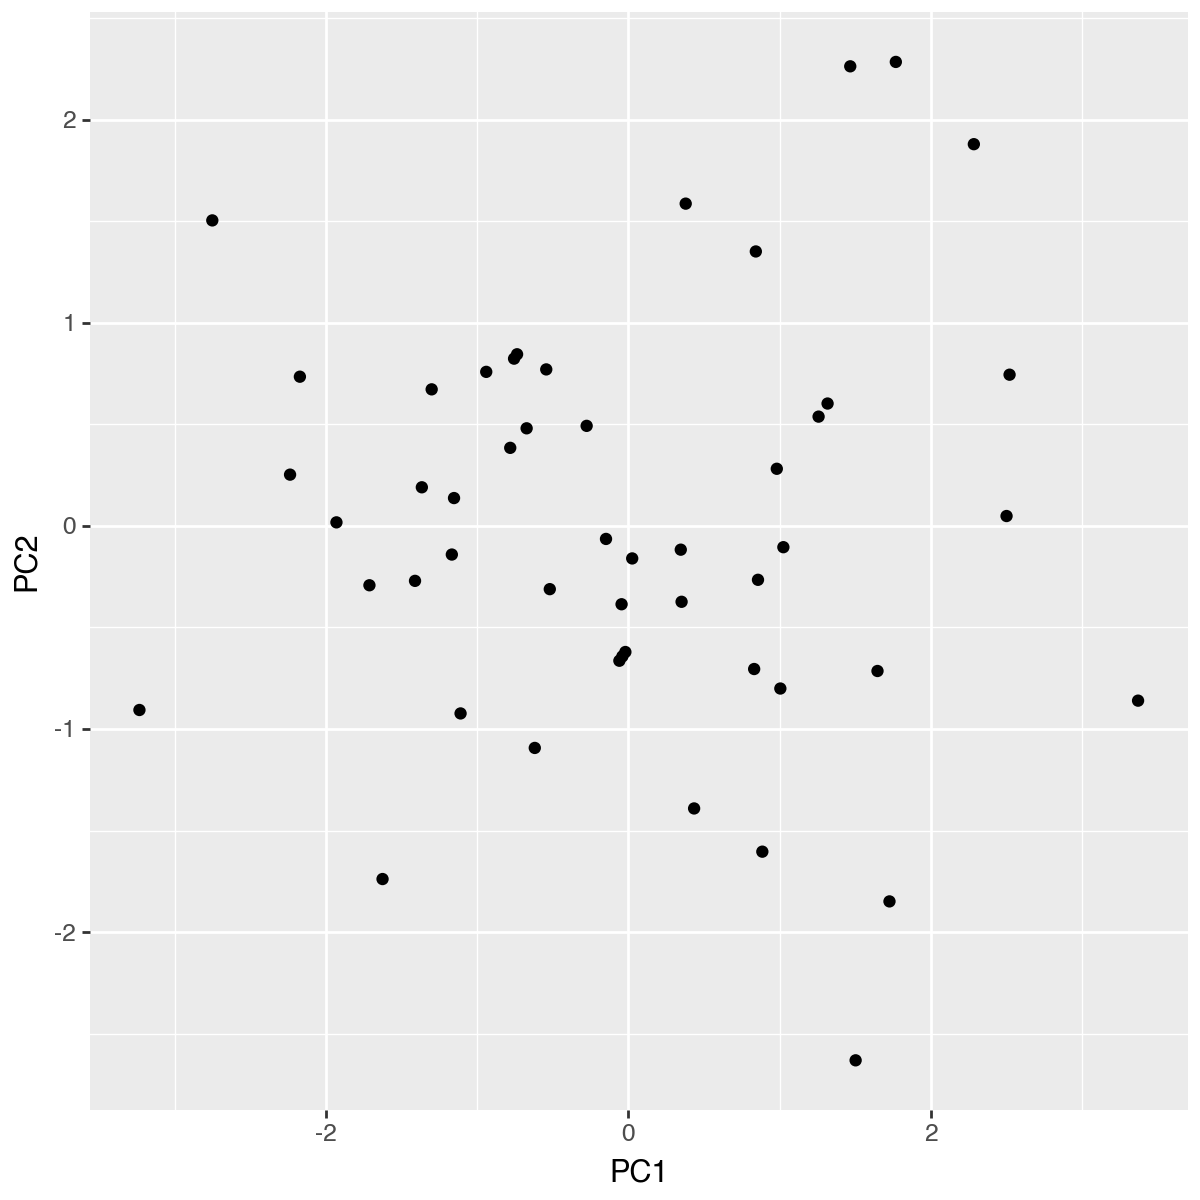

In [309]:
p = (
    ggplot(scores_df, aes('PC1', 'PC2')) + 
    geom_point() + 
    theme(figure_size= (6,6))
)

p

In the biplot one can observe, that all lengths and widths contribute with the same sign to the PC1. 

PC1 correlates positively with the projection of the axes of the variables in the original dataset (red vectors).
An increase in the size of the flower implies an increase in the projected PC1 value. We can assume that
the PC1 describes the size of the flower.

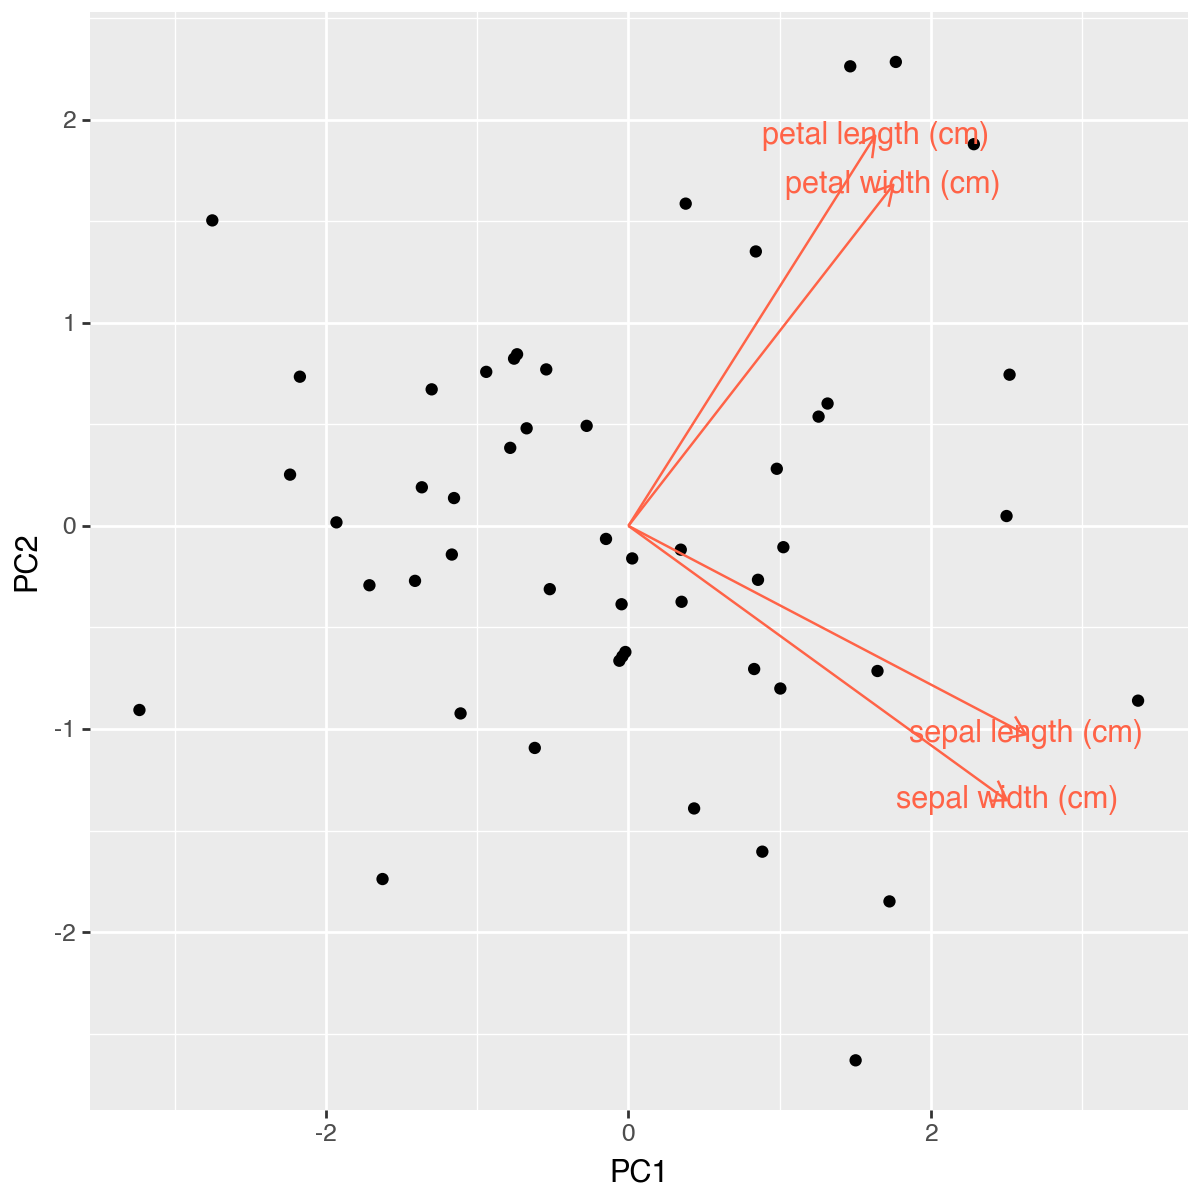

In [310]:
scale_x = scores_df['PC1'].std() * 3 # Scale loadings to fit the space
scale_y = scores_df['PC2'].std() * 3
load_df = pd.DataFrame({'xstart': 0.0, 'ystart': 0.0, 'label': iris_pca.columns,
'xend': pca_res.components_.T[:,0] * scale_x,
'yend': pca_res.components_.T[:,1] * scale_y})
(p + geom_segment(load_df, aes(x='xstart', y='ystart', xend='xend', yend='yend'), \
color='tomato', arrow=arrow(length=0.1))
+ geom_text(load_df, aes('xend', 'yend', label='label'), color='tomato')
)

4. Plot the first principal component against the other variables in the dataset and discuss whether this
supports your previously stated interpretation.

In [311]:
pc_iris = pd.concat([iris_df.loc[iris_df["target"]=="setosa"], scores_df], axis=1)

pc_iris = pc_iris.melt(id_vars=["target", 'PC1', 'PC2', 'PC3', 'PC4'])

pc_iris.head()

,target,PC1,PC2,PC3,PC4,variable,value
0,setosa,-0.039815,-0.642576,-0.097234,0.099546,sepal length (cm),5.1
1,setosa,-1.153210,0.136821,-0.057675,0.604718,sepal length (cm),4.9
2,setosa,-1.411224,-0.270827,0.374379,-0.124312,sepal length (cm),4.7
3,setosa,-1.301071,0.672035,-0.393782,-0.248046,sepal length (cm),4.6
4,setosa,-0.059633,-0.664054,-0.078121,-0.290225,sepal length (cm),5.0


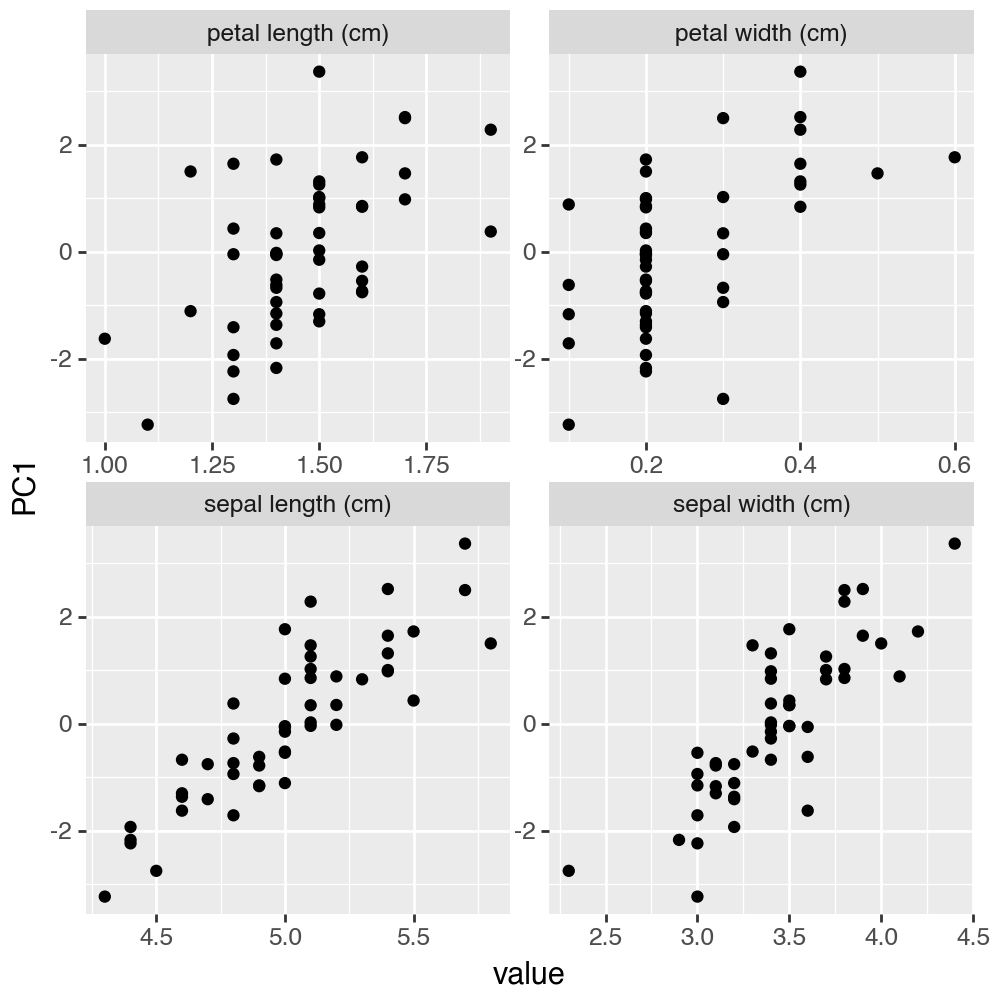

In [312]:
(
    ggplot(pc_iris, aes("value", "PC1")) + 
    geom_point() + 
    facet_wrap("~variable", scales = 'free') +
    theme(figure_size=(5,5))
)

We see that PC1 is also positively correlated with the raw data which supports our previous observation.

5. Repeat the steps 1 - 4 for all species jointly (not only setosa). Discuss whether your original
interpretation of the first principal component changed when performing the PCA for all species jointly.
Use color to differentiate between the species in your plots.

In [313]:
pca_data = iris_df.iloc[:,:-1]

X = sklearn.preprocessing.StandardScaler().fit_transform(pca_data)
pca_res = sklearn.decomposition.PCA().fit(X)

sum_df = pd.DataFrame({
'Variance': pca_res.explained_variance_,
'Proportion of Variance': pca_res.explained_variance_ratio_,
'Cumulative Proportion': np.cumsum(pca_res.explained_variance_ratio_)
}, index=[f'PC{i+1}' for i in range(pca_res.n_components_)])
sum_df

,Variance,Proportion of Variance,Cumulative Proportion
PC1,2.938085,0.729624,0.729624
PC2,0.920165,0.228508,0.958132
PC3,0.147742,0.036689,0.994821
PC4,0.020854,0.005179,1.000000


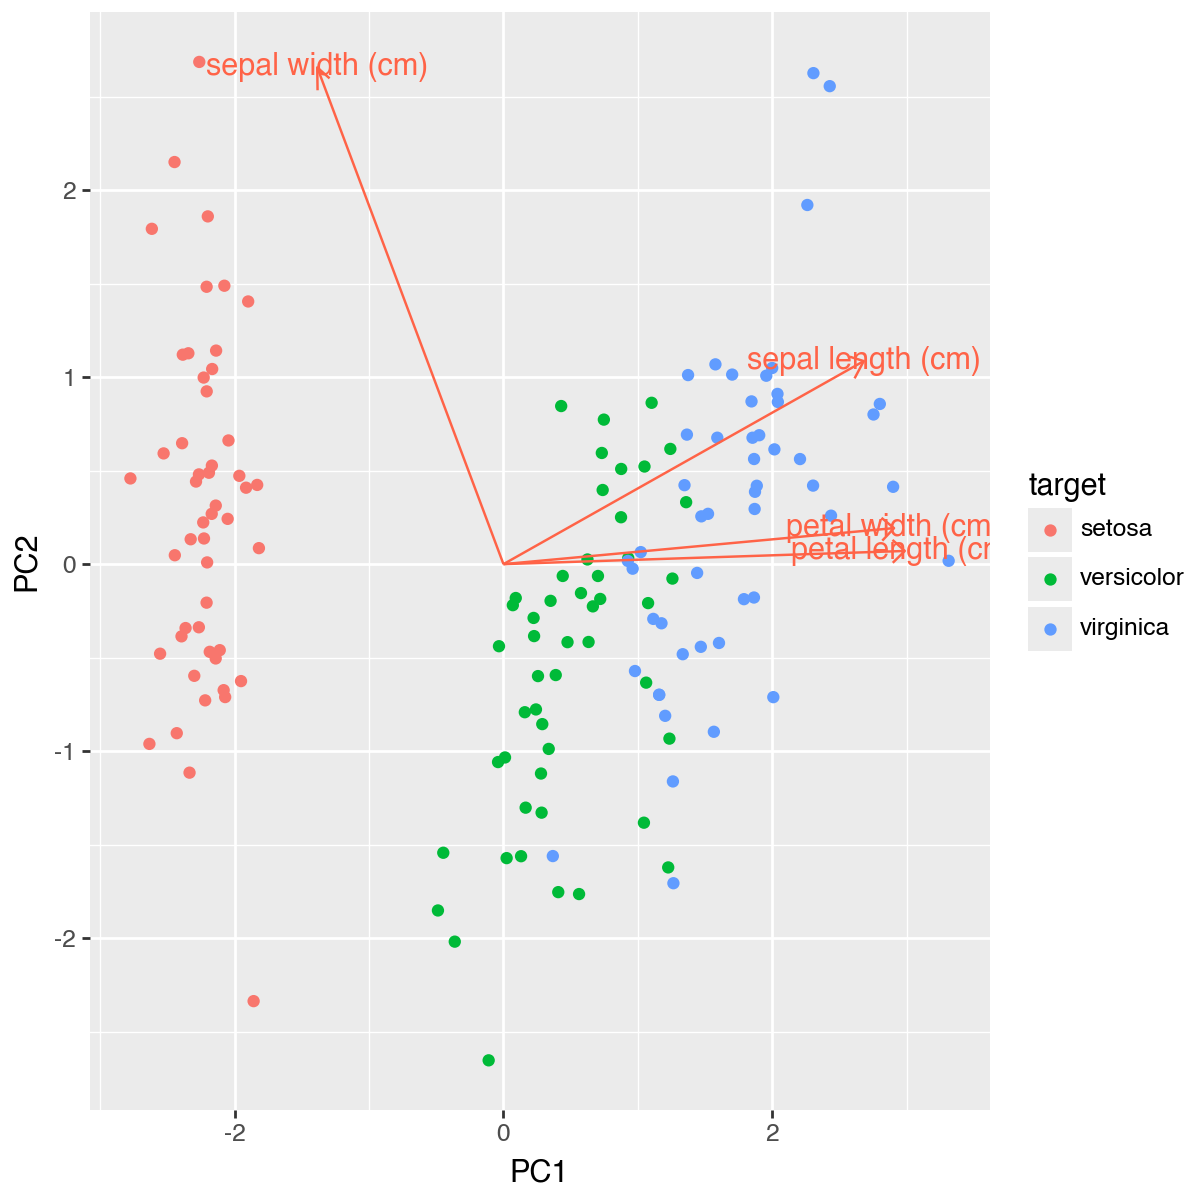

In [314]:
scores_df = pd.DataFrame(pca_res.transform(X), columns = [f'PC{i+1}' \
for i in range(pca_res.n_components_)], index=pca_data.index)

pc_iris = pd.concat([iris_df, scores_df], axis=1)

p = (
    ggplot(pc_iris, aes('PC1', 'PC2', color="target")) + 
    geom_point() + 
    theme(figure_size=(6,6))
)

scale_x = scores_df['PC1'].std() * 3 # Scale loadings to fit the space
scale_y = scores_df['PC2'].std() * 3
load_df = pd.DataFrame({'xstart': 0.0, 'ystart': 0.0, 'label': pca_data.columns,
'xend': pca_res.components_.T[:,0] * scale_x,
'yend': pca_res.components_.T[:,1] * scale_y})

(p + geom_segment(load_df, aes(x='xstart', y='ystart', xend='xend', yend='yend'), \
color='tomato', arrow=arrow(length=0.1))
+ geom_text(load_df, aes('xend', 'yend', label='label'), color='tomato'))

In the plot above one can see that the first principal component clearly seperates the species. 

In the
biplot one can observe that the sepal width vs the others do not contribute with the same sign any longer.

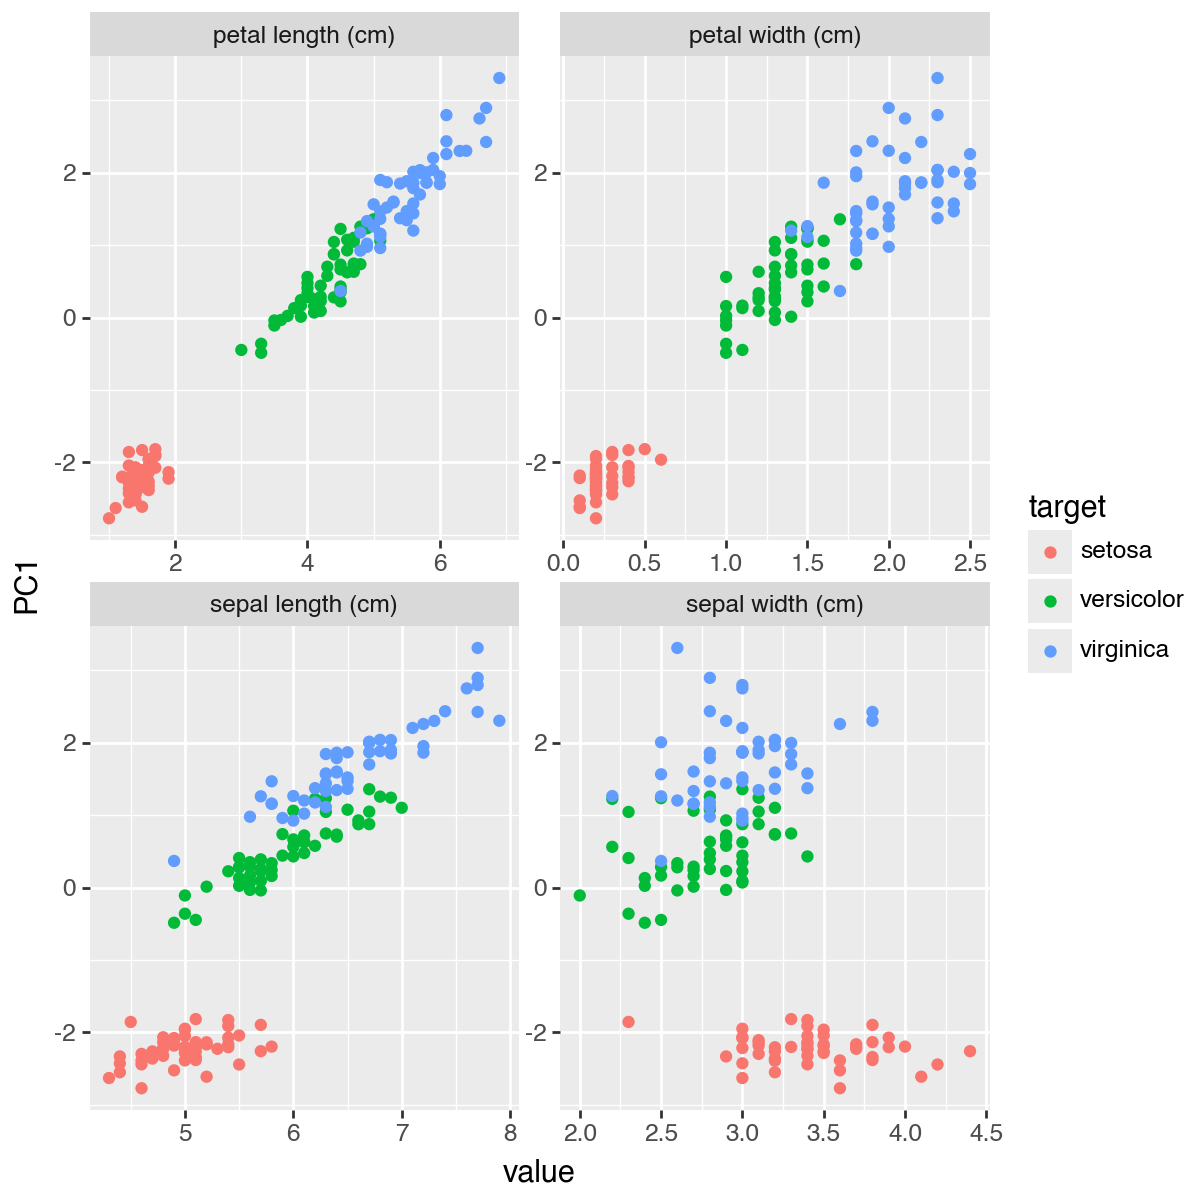

In [315]:
pc_iris = pc_iris.melt(id_vars=["target", 'PC1', 'PC2', 'PC3', 'PC4'])

(
    ggplot(pc_iris, aes("value", "PC1", color="target")) + 
    geom_point() + 
    facet_wrap("~variable", scales = 'free') + 
    theme(figure_size= (6,6))
)

The PC1 strongly associates with the size of the petal wich strongly associates with the species. 

Additionally, it is negatively correlated with the sepal width, as the sepal width is higher for setosa than for the other species. 

Therefore, the PC1 can be interpreted as describing the species of each flower.